# Melbourne Housing Market: Data Analysis, Economic Trends & Price Prediction

### Importing the necessary libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

### Loading the dataset

In [4]:
df = pd.read_csv('data/Melbourne_housing_FULL.csv')
df.head(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


In [5]:
abs_data = pd.read_excel("data/ABS_dwelling_data.xlsx",sheet_name='Data1',skiprows=9)
abs_data.head(4)

,Series ID,A83728603C,A83728608R,A83728613J,A83728618V,A83728623L,A83728628X,A83728633T,A83728638C,A83728643W,...,A83728647F,A83728605J,A83728610A,A83728615L,A83728620F,A83728625T,A83728630K,A83728635W,A83728640R,A83728645A
0,2011-09-01,1453495.0,1121374.8,723858.5,253939.4,464342.1,65479.7,30196.1,72384.2,4185069.8,...,490.8,2839.0,2265.6,1784.5,722.3,942.0,230.5,74.0,144.9,9002.7
1,2011-12-01,1442134.3,1114587.1,721480.1,257468.3,463152.5,66647.4,27445.0,74701.4,4167616.1,...,486.9,2845.1,2278.3,1791.7,724.6,946.3,231.1,74.4,145.8,9037.2
2,2012-03-01,1476077.7,1104613.8,717810.5,253614.0,474579.7,65710.3,26899.0,73903.0,4193208.0,...,488.6,2850.3,2287.7,1796.2,726.3,950.2,231.6,74.7,146.4,9063.4
3,2012-06-01,1492911.0,1110654.2,722320.4,254790.2,475476.2,63755.8,26825.8,74278.5,4221012.0,...,489.9,2856.3,2299.2,1803.9,728.5,954.9,232.1,75.1,147.5,9097.6


### Macro-Level Analysis of Victorian Housing Prices

In this section, I explore the ABS housing dataset to understand the macro trends in Victorian dwelling prices.
First, I select the relevant columns and rename them so they are easier to understand and work with.

In [6]:
abs_data=abs_data[['Series ID', 'A83728612F']]
abs_data.rename(columns={'Series ID': 'Quarter','A83728612F':'Mean_Dwelling_Price_VIC'},inplace=True)
abs_data.head(4)

,Quarter,Mean_Dwelling_Price_VIC
0,2011-09-01,512.6
1,2011-12-01,506.6
2,2012-03-01,500.0
3,2012-06-01,500.2


### Understanding the Dataset

Next, I explore the dataset to understand its structure and summary statistics.
This helps identify the data types, number of observations, and general distribution of housing prices.

In [7]:
abs_data.describe()

,Quarter,Mean_Dwelling_Price_VIC
count,57,57.000000
mean,2018-08-31 13:28:25.263158,722.847368
min,2011-09-01 00:00:00,491.700000
25%,2015-03-01 00:00:00,581.500000
50%,2018-09-01 00:00:00,717.600000
75%,2022-03-01 00:00:00,900.900000
max,2025-09-01 00:00:00,942.200000
std,NaN,153.076729


In [8]:
abs_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Quarter                  57 non-null     datetime64[us]
 1   Mean_Dwelling_Price_VIC  57 non-null     float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 1.0 KB


### Extracting Year from Quarter

To analyse price trends over time, I extract the year from the quarter column.

In [9]:
abs_data['Year']=abs_data['Quarter'].dt.year
abs_data.head(5)

,Quarter,Mean_Dwelling_Price_VIC,Year
0,2011-09-01,512.6,2011
1,2011-12-01,506.6,2011
2,2012-03-01,500.0,2012
3,2012-06-01,500.2,2012
4,2012-09-01,491.7,2012


### Checking Dataset Shape and Values

Here I check the size of the dataset and unique year values to understand the time range covered in the data.

In [10]:
abs_data.shape

(57, 3)

In [11]:
abs_data=abs_data[abs_data['Year']>=2017]
abs_data = abs_data.reset_index(drop=True)

In [12]:
abs_data.shape

(35, 3)

In [13]:
abs_data['Year'].unique()

array([2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])

### Checking for Missing Values

Before continuing the analysis, I verify if the dataset contains any missing values.

In [14]:
abs_data.isnull().any()

Quarter                    False
Mean_Dwelling_Price_VIC    False
Year                       False
dtype: bool

In [15]:
abs_data.head()

,Quarter,Mean_Dwelling_Price_VIC,Year
0,2017-03-01,695.6,2017
1,2017-06-01,723.8,2017
2,2017-09-01,717.6,2017
3,2017-12-01,746.9,2017
4,2018-03-01,743.7,2018


### Creating COVID Time Period Categories

To analyse the impact of COVID-19 on housing prices, the dataset is divided into three time periods:

- **Pre-COVID**: Years before 2020  
- **COVID Period**: Years 2020 to 2021  
- **Post-COVID**: Years after 2021  

This categorisation helps compare housing price trends across different economic periods.

In [16]:
def covid_period(year):
    if year<=2019:
        return 'Pre Covid'
    elif year>=2020 and year<=2021:
        return 'Covid'
    else:
        return 'Post Covid'

abs_data['Period']=abs_data['Year'].apply(covid_period)
abs_data.head()

,Quarter,Mean_Dwelling_Price_VIC,Year,Period
0,2017-03-01,695.6,2017,Pre Covid
1,2017-06-01,723.8,2017,Pre Covid
2,2017-09-01,717.6,2017,Pre Covid
3,2017-12-01,746.9,2017,Pre Covid
4,2018-03-01,743.7,2018,Pre Covid


### Saving the Cleaned Dataset

- After cleaning and preparing the macro housing data, the dataset is saved as a new CSV file.  
- This allows the cleaned data to be reused later for further analysis and visualization without repeating the preprocessing steps.

In [69]:
abs_data.to_csv('cleaned_data/macro_vic_clean.csv', index=False)

### Average Housing Price by COVID Period

- To understand how housing prices changed across different time periods, the average dwelling price is calculated for each COVID period (Pre-COVID, COVID, and Post-COVID).
- This helps compare how the housing market behaved before, during, and after the pandemic.

In [18]:
# average price per period
avg_by_period=abs_data.groupby('Period')['Mean_Dwelling_Price_VIC'].mean()
avg_by_period

Period
Covid         826.112500
Post Covid    910.246667
Pre Covid     719.150000
Name: Mean_Dwelling_Price_VIC, dtype: float64

### Insight
The results show a clear increase in average dwelling prices across the three periods.
- **Pre-COVID:** Average price was **719.15**
- **COVID Period:** Prices increased to **826.11**
- **Post-COVID:** Prices further increased to **910.25**
This indicates that housing prices in Victoria continued to rise during and after the COVID period.

### Percentage Change in Housing Prices

To understand how housing prices changed across different periods, I calculate the percentage increase between **Pre-COVID, COVID, and Post-COVID** periods.

This helps show how much the housing market grew during the pandemic and after it.

In [19]:
pre=avg_by_period['Pre Covid']
covid=avg_by_period['Covid']
post=avg_by_period['Post Covid']

In [20]:
pre_to_covid=((covid-pre)/pre)*100
covid_to_post=((post-covid)/covid)*100
pre_to_post=((post-pre)/post)*100

In [21]:
print(f"Pre to Covid: {pre_to_covid:.2f}%")
print(f"Covid to Post: {covid_to_post:.2f}%")
print(f"Pre to Post: {pre_to_post:.2f}%")

Pre to Covid: 14.87%
Covid to Post: 10.18%
Pre to Post: 20.99%


### Insight

- Prices increased **14.87% from Pre-COVID to COVID**.
- Prices increased **10.18% from COVID to Post-COVID**.
- Overall, prices increased **20.99% from Pre-COVID to Post-COVID**.

Economically, this suggests that strong housing demand and low interest rates during and after COVID may have contributed to the continued rise in housing prices.

### Peak and Lowest Housing Prices Across Periods

Here I check the **highest and lowest housing prices** across the three time periods to see how the market behaved during these stages.


In [22]:
pre_covid_peak=abs_data[abs_data['Period']=='Pre Covid']['Mean_Dwelling_Price_VIC'].max()
covid_low_price=abs_data[abs_data['Period']=='Covid']['Mean_Dwelling_Price_VIC'].min()
post_covid_peak=abs_data[abs_data['Period']=='Post Covid']['Mean_Dwelling_Price_VIC'].max()

print(f"pre_covid_peak: {pre_covid_peak:.2f}")
print(f"covid_low_price: {covid_low_price:.2f}")
print(f"post_covid_peak: {post_covid_peak:.2f}")

pre_covid_peak: 749.10
covid_low_price: 748.60
post_covid_peak: 942.20


This shows that although prices slightly dropped during COVID, they increased significantly in the post-COVID period.

### Price Drop During COVID

Here I check how much housing prices dropped during the COVID period.

I compare the **price just before COVID (2019 Q4)** with the **lowest price during the COVID period** to calculate the percentage drop in housing prices.

In [23]:
#covid
pre_covid_price=abs_data[abs_data['Quarter']=='2019-12-01']['Mean_Dwelling_Price_VIC'].values[0]
covid_low_price=abs_data[abs_data['Period']=='Covid']['Mean_Dwelling_Price_VIC'].min()
covid_drop_percent = ((covid_low_price - pre_covid_price) / pre_covid_price) * 100
covid_drop_percent

-0.06674676278200507

- The housing price dropped by **about 0.07% during the COVID period** compared to the price just before COVID.
- This shows that the housing market experienced a **very small decline during COVID** before prices started increasing again.

### Housing Price Recovery After COVID

Here I calculate how much housing prices increased after the lowest point during the COVID period.
I compare the **lowest price during COVID** with the **highest price in the Post-COVID period** to see how strongly the housing market recovered.

In [24]:
#pre_covid_price=abs_data[abs_data['Quarter']=='2019-12-01']['Mean_Dwelling_Price_VIC'].values[0]
covid_max_price=abs_data[abs_data['Period']=='Covid']['Mean_Dwelling_Price_VIC'].max()
post_covid_price=abs_data[abs_data['Period']=='Post Covid']['Mean_Dwelling_Price_VIC'].max()
covid_recovery=((post_covid_price-covid_low_price)/covid_low_price)*100
covid_recovery

25.861608335559715

Housing prices increased by **about 25.86% after the COVID period** compared to the lowest price during COVID.
This shows that the housing market **recovered strongly in the post-COVID period**.

### Quarterly Percentage Change in Housing Prices

To understand short-term market movements, I calculate the **quarterly percentage change** in dwelling prices.This shows how housing prices increased or decreased from one quarter to the next.

In [25]:
#quarterly change
abs_data=abs_data.sort_values('Quarter')
abs_data['Quarterly_%_Change']=abs_data['Mean_Dwelling_Price_VIC'].pct_change() * 100
abs_data.head()

,Quarter,Mean_Dwelling_Price_VIC,Year,Period,Quarterly_%_Change
0,2017-03-01,695.6,2017,Pre Covid,NaN
1,2017-06-01,723.8,2017,Pre Covid,4.054054
2,2017-09-01,717.6,2017,Pre Covid,-0.856590
3,2017-12-01,746.9,2017,Pre Covid,4.083055
4,2018-03-01,743.7,2018,Pre Covid,-0.428438


### Quarterly Housing Price Change Trend

To visualize how housing prices changed over time, I plot the **quarterly percentage change in dwelling prices**.
This helps identify periods where housing prices increased or decreased more sharply.

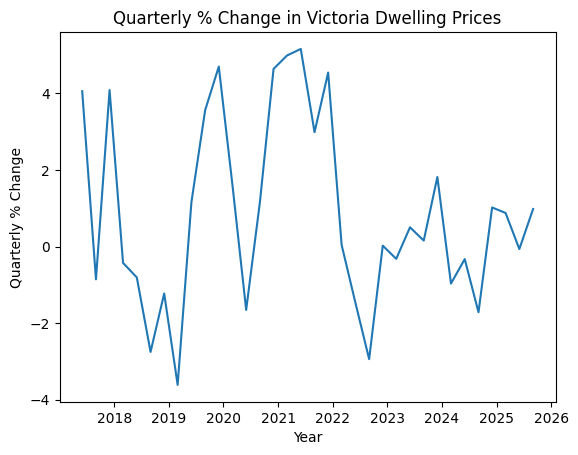

In [26]:
#quarter plot
plt.plot(abs_data['Quarter'],abs_data['Quarterly_%_Change'])
plt.xlabel('Year')
plt.ylabel('Quarterly % Change')
plt.title("Quarterly % Change in Victoria Dwelling Prices")
plt.show()

Housing prices experienced noticeable fluctuations over time, with both increases and declines in quarterly growth across different periods.

In [27]:
abs_data['Quarterly_%_Change'].describe()

count    34.000000
mean      0.849748
std       2.453662
min      -3.612758
25%      -0.844137
50%       0.327973
75%       2.691044
max       5.156870
Name: Quarterly_%_Change, dtype: float64

### Yearly Housing Price Trend

Here I calculate the **average dwelling price for each year** and plot it to see how housing prices in Victoria changed over time.

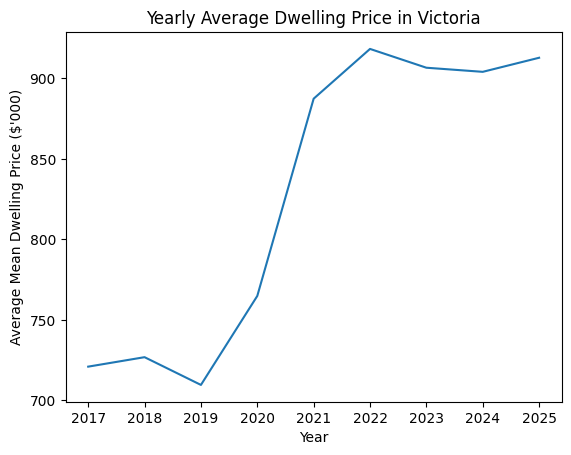

In [28]:
year_growth=abs_data.groupby('Year')['Mean_Dwelling_Price_VIC'].mean()
year_growth.plot()
plt.ylabel("Average Mean Dwelling Price ($'000)")
plt.title("Yearly Average Dwelling Price in Victoria")
plt.show()

Average dwelling prices in Victoria show a strong upward trend after 2020, indicating significant growth in the housing market following the COVID period.

###  Housing Price Volatility

Here I check how much housing prices fluctuated across different periods by calculating the **standard deviation of quarterly price changes**.
Higher values mean prices changed more during that period.

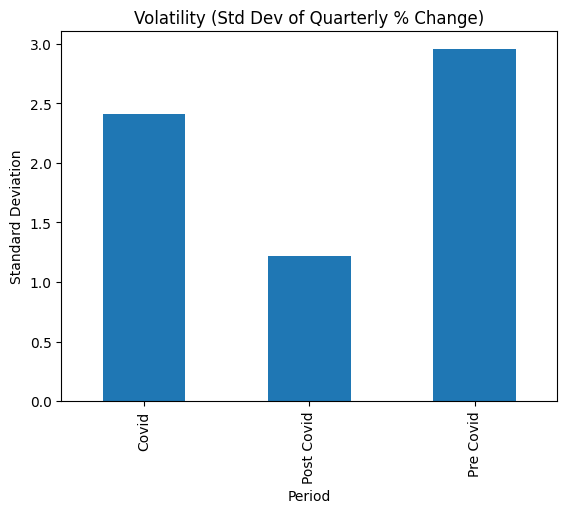

In [29]:
volatility_change=abs_data.groupby('Period')['Quarterly_%_Change'].std()
volatility_change.plot(kind='bar')
plt.title("Volatility (Std Dev of Quarterly % Change)")
plt.ylabel("Standard Deviation")
plt.show()

Housing prices were **most volatile during the Pre-COVID period**, while the **Post-COVID period shows the least volatility**, indicating more stable price changes.

### Comparing Yearly Housing Price Growth

Here I calculate the **average yearly growth in housing prices** and compare how the growth changed across different periods (Pre-COVID, COVID, and Post-COVID).
This helps understand how the housing market growth behaved during these economic periods.

In [30]:
#growth 
yearly_avg=abs_data.groupby('Year')['Mean_Dwelling_Price_VIC'].mean()
yearly_growth=yearly_avg.pct_change()*100
yearly_df = pd.DataFrame({
    'Year': yearly_avg.index,
    'Avg_Price': yearly_avg.values,
    'Yearly_Growth_%': yearly_growth.values
})
yearly_df = yearly_df.dropna()
yearly_df['Period'] = yearly_df['Year'].apply(covid_period)
growth_comparison = yearly_df.groupby('Period')['Yearly_Growth_%'].mean()

growth_comparison

Period
Covid         11.899111
Post Covid     0.724133
Pre Covid     -0.777473
Name: Yearly_Growth_%, dtype: float64

### Insight
- During the **COVID period**, housing prices had the highest average growth (**about 11.9%**).
- The **Pre-COVID period** shows slightly negative growth.
- In the **Post-COVID period**, growth slowed down and became more stable.

##  Micro-Level Housing Analysis

- In this section, I analyse the **Melbourne housing dataset at the property level**.
- Unlike the macro analysis (which looked at overall housing price trends), this part focuses on **individual property features** such as location, type, rooms, distance from CBD, etc.
- This helps understand **what factors influence housing prices** and prepares the data for the machine learning models.

## Micro-Level Housing Analysis

In this section, I explore the Melbourne housing dataset at the property level.  
This helps understand the structure of the data and the main features that influence housing prices.

In [31]:
### Micro analysis
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


### Preparing the Data for Analysis

- Here I prepare the dataset for analysis. First, I convert the **Date column** to datetime format and extract the **year** from it.

- Then I create a **COVID period category (Pre-COVID, COVID, Post-COVID)** based on the year. Finally, I filter the dataset to keep data from **2017 onwards** for the analysis.

In [32]:
df.shape

(34857, 21)

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  str    
 1   Address        34857 non-null  str    
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  str    
 4   Price          27247 non-null  float64
 5   Method         34857 non-null  str    
 6   SellerG        34857 non-null  str    
 7   Date           34857 non-null  str    
 8   Distance       34856 non-null  float64
 9   Postcode       34856 non-null  float64
 10  Bedroom2       26640 non-null  float64
 11  Bathroom       26631 non-null  float64
 12  Car            26129 non-null  float64
 13  Landsize       23047 non-null  float64
 14  BuildingArea   13742 non-null  float64
 15  YearBuilt      15551 non-null  float64
 16  CouncilArea    34854 non-null  str    
 17  Lattitude      26881 non-null  float64
 18  Longtitude     26

In [34]:
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,34857.000000,2.724700e+04,34856.000000,34856.000000,26640.000000,26631.000000,26129.000000,23047.000000,13742.00000,15551.000000,26881.000000,26881.000000,34854.000000
mean,3.031012,1.050173e+06,11.184929,3116.062859,3.084647,1.624798,1.728845,593.598993,160.25640,1965.289885,-37.810634,145.001851,7572.888306
std,0.969933,6.414671e+05,6.788892,109.023903,0.980690,0.724212,1.010771,3398.841946,401.26706,37.328178,0.090279,0.120169,4428.090313
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1196.000000,-38.190430,144.423790,83.000000
25%,2.000000,6.350000e+05,6.400000,3051.000000,2.000000,1.000000,1.000000,224.000000,102.00000,1940.000000,-37.862950,144.933500,4385.000000
50%,3.000000,8.700000e+05,10.300000,3103.000000,3.000000,2.000000,2.000000,521.000000,136.00000,1970.000000,-37.807600,145.007800,6763.000000
75%,4.000000,1.295000e+06,14.000000,3156.000000,4.000000,2.000000,2.000000,670.000000,188.00000,2000.000000,-37.754100,145.071900,10412.000000
max,16.000000,1.120000e+07,48.100000,3978.000000,30.000000,12.000000,26.000000,433014.000000,44515.00000,2106.000000,-37.390200,145.526350,21650.000000


In [35]:
df.isnull().sum()

Suburb               0
Address              0
Rooms                0
Type                 0
Price             7610
Method               0
SellerG              0
Date                 0
Distance             1
Postcode             1
Bedroom2          8217
Bathroom          8226
Car               8728
Landsize         11810
BuildingArea     21115
YearBuilt        19306
CouncilArea          3
Lattitude         7976
Longtitude        7976
Regionname           3
Propertycount        3
dtype: int64

In [36]:
#outliers
## date column change
df['Date']=pd.to_datetime(df['Date'],dayfirst=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Suburb         34857 non-null  str           
 1   Address        34857 non-null  str           
 2   Rooms          34857 non-null  int64         
 3   Type           34857 non-null  str           
 4   Price          27247 non-null  float64       
 5   Method         34857 non-null  str           
 6   SellerG        34857 non-null  str           
 7   Date           34857 non-null  datetime64[us]
 8   Distance       34856 non-null  float64       
 9   Postcode       34856 non-null  float64       
 10  Bedroom2       26640 non-null  float64       
 11  Bathroom       26631 non-null  float64       
 12  Car            26129 non-null  float64       
 13  Landsize       23047 non-null  float64       
 14  BuildingArea   13742 non-null  float64       
 15  YearBuilt      15551 non-null 

In [37]:
df['Year']=df['Date'].dt.year
df['Period']=df['Year'].apply(covid_period)
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Year,Period
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,2016-09-03,2.5,3067.0,...,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0,2016,Pre Covid
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-12-03,2.5,3067.0,...,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0,2016,Pre Covid
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-02-04,2.5,3067.0,...,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0,2016,Pre Covid
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,2016-02-04,2.5,3067.0,...,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0,2016,Pre Covid
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-03-04,2.5,3067.0,...,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0,2017,Pre Covid


In [38]:
df=df[df['Year']>=2017].reset_index(drop=True)
df.Year.unique()

array([2017, 2018])

### Data Cleaning

In this step, I clean the dataset to make it ready for analysis and modelling.

- Rows with missing **Price values** are removed.
- Some columns that are not required for the analysis are dropped.
- Missing values in numerical columns are filled using the **median**.
- Missing values in categorical columns are filled using the **most frequent value (mode)**.

This helps ensure the dataset is complete and suitable for further analysis.

In [39]:
df = df.dropna(subset=['Price'])
df.shape

(19193, 23)

In [40]:
df = df.drop(columns=['BuildingArea','YearBuilt','Landsize','Lattitude','Longtitude'])
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,CouncilArea,Regionname,Propertycount,Year,Period
0,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-03-04,2.5,3067.0,3.0,2.0,0.0,Yarra City Council,Northern Metropolitan,4019.0,2017,Pre Covid
1,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2017-03-04,2.5,3067.0,3.0,2.0,1.0,Yarra City Council,Northern Metropolitan,4019.0,2017,Pre Covid
2,Abbotsford,3/72 Charles St,4,h,1330000.0,PI,Kay,2017-03-18,2.5,3067.0,4.0,2.0,2.0,Yarra City Council,Northern Metropolitan,4019.0,2017,Pre Covid
4,Abbotsford,13/11 Nicholson St,3,t,900000.0,S,Beller,2017-03-18,2.5,3067.0,3.0,2.0,2.0,Yarra City Council,Northern Metropolitan,4019.0,2017,Pre Covid
5,Abbotsford,138/56 Nicholson St,3,u,1090000.0,S,Jellis,2017-03-18,2.5,3067.0,3.0,2.0,2.0,Yarra City Council,Northern Metropolitan,4019.0,2017,Pre Covid


In [41]:
df.isnull().sum()

Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            1
Postcode            1
Bedroom2         4733
Bathroom         4739
Car              5116
CouncilArea         3
Regionname          3
Propertycount       3
Year                0
Period              0
dtype: int64

In [42]:
df['Bedroom2'] = df['Bedroom2'].fillna(df['Bedroom2'].median())
df['Bathroom'] = df['Bathroom'].fillna(df['Bathroom'].median())
df['Car'] = df['Car'].fillna(df['Car'].median())
df['Distance'] = df['Distance'].fillna(df['Distance'].median())
df['Propertycount'] = df['Propertycount'].fillna(df['Propertycount'].median())

df['CouncilArea'] = df['CouncilArea'].fillna(df['CouncilArea'].mode()[0])
df['Regionname'] = df['Regionname'].fillna(df['Regionname'].mode()[0])

In [43]:
df['Postcode'] = df['Postcode'].fillna(df['Postcode'].mode()[0])
df.isnull().sum()

Suburb           0
Address          0
Rooms            0
Type             0
Price            0
Method           0
SellerG          0
Date             0
Distance         0
Postcode         0
Bedroom2         0
Bathroom         0
Car              0
CouncilArea      0
Regionname       0
Propertycount    0
Year             0
Period           0
dtype: int64

In [44]:
df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'CouncilArea', 'Regionname', 'Propertycount', 'Year', 'Period'],
      dtype='str')

In [45]:
df.describe()

,Rooms,Price,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Propertycount,Year
count,19193.000000,1.919300e+04,19193,19193.000000,19193.000000,19193.000000,19193.000000,19193.000000,19193.000000,19193.000000
mean,3.049497,1.044696e+06,2017-09-15 03:39:04.792372,12.335997,3121.415777,3.117387,1.721565,1.854270,7578.860209,2017.191424
min,1.000000,1.120000e+05,2017-02-11 00:00:00,0.000000,3000.000000,0.000000,0.000000,0.000000,83.000000,2017.000000
25%,2.000000,6.400000e+05,2017-06-24 00:00:00,6.800000,3047.000000,3.000000,1.000000,1.000000,4294.000000,2017.000000
50%,3.000000,8.670000e+05,2017-09-16 00:00:00,11.200000,3095.000000,3.000000,2.000000,2.000000,6567.000000,2017.000000
75%,4.000000,1.280000e+06,2017-11-25 00:00:00,16.100000,3163.000000,3.000000,2.000000,2.000000,10412.000000,2017.000000
max,16.000000,1.120000e+07,2018-03-17 00:00:00,48.100000,3978.000000,16.000000,9.000000,18.000000,21650.000000,2018.000000
std,0.943843,6.344804e+05,NaN,7.494491,125.850223,0.806217,0.625882,0.879559,4453.894899,0.393432


### Outlier Detection and Handling

- In this step, I detect and handle outliers in the dataset.
- First, I remove extreme values in the **Price column** using the IQR method.  
- Then I correct unrealistic values in other columns such as **Bedroom2, Bathroom, Car, and Rooms** to keep the data consistent.
Finally, some unnecessary columns that are not required for the analysis are dropped.

In [46]:
## outliers detection
## price outlier detection:
IQR=df['Price'].quantile(0.75)-df['Price'].quantile(0.25)
upr=df['Price'].quantile(0.75)+1.5*IQR
lwr=df['Price'].quantile(0.25)-1.5*IQR
df=df[(df['Price']>=lwr)&(df['Price']<=upr)]
df.shape

(18275, 18)

In [47]:
#handling other columns outliers
#bedrrom 
df.loc[df['Bedroom2']>df['Rooms'],'Bedroom2']=df['Rooms']
df.loc[df['Bathroom']>df['Bedroom2'],'Bathroom']=df['Bedroom2']
df.loc[df['Car']>df['Rooms'],'Car']=df['Rooms']

df.loc[df['Rooms']>10,'Rooms']=10
df.loc[df['Bedroom2']>10,'Bedroom2']=8
df.loc[df['Bathroom']>10,'Bathroom']=6
df.loc[df['Car']>6,'Car']=6

In [48]:
df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'CouncilArea', 'Regionname', 'Propertycount', 'Year', 'Period'],
      dtype='str')

In [49]:
df.drop(columns=['Address','SellerG','Date','Period'],inplace=True)
df.head()

,Suburb,Rooms,Type,Price,Method,Distance,Postcode,Bedroom2,Bathroom,Car,CouncilArea,Regionname,Propertycount,Year
0,Abbotsford,3,h,1465000.0,SP,2.5,3067.0,3.0,2.0,0.0,Yarra City Council,Northern Metropolitan,4019.0,2017
1,Abbotsford,3,h,850000.0,PI,2.5,3067.0,3.0,2.0,1.0,Yarra City Council,Northern Metropolitan,4019.0,2017
2,Abbotsford,4,h,1330000.0,PI,2.5,3067.0,4.0,2.0,2.0,Yarra City Council,Northern Metropolitan,4019.0,2017
4,Abbotsford,3,t,900000.0,S,2.5,3067.0,3.0,2.0,2.0,Yarra City Council,Northern Metropolitan,4019.0,2017
5,Abbotsford,3,u,1090000.0,S,2.5,3067.0,3.0,2.0,2.0,Yarra City Council,Northern Metropolitan,4019.0,2017


### Saving the Cleaned Dataset
After completing the data cleaning and preprocessing steps, the cleaned housing dataset is saved as a new CSV file.  
This allows the dataset to be reused later for further analysis and machine learning modelling.

In [70]:
df.to_csv('cleaned_data/cleaned_housing_data.csv',index=False)

### Preparing Data for Machine Learning

Before building the models, categorical variables are converted into numerical format using **one-hot encoding**.
Then the dataset is split into:
- **X (features)**: all input variables used to predict the price  
- **Y (target variable)**: the housing **Price** that the model will learn to predict.

In [51]:
df=pd.get_dummies(df,drop_first=True)
X = df.drop(columns=['Price'])
Y=df.Price

### Linear Regression Model
Here I train a **Linear Regression model** to predict housing prices.  
The data is split into **training and testing sets**, and the model performance is checked using **R² score and MAE**.

In [52]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2)

model=LinearRegression()
model.fit(X_train,Y_train)
model.score(X_test,Y_test)

predictions = model.predict(X_test)

In [53]:
print("MAE:", mean_absolute_error(Y_test, predictions))
print("R2 Score:", r2_score(Y_test, predictions))

MAE: 165481.54766463718
R2 Score: 0.7219023108861616


In [54]:
model.score(X_test,Y_test)

0.7219023108861616

### Model Result

The model achieved an **R² score of 0.73**, meaning it explains about **73% of the price variation**.  
The **MAE is around 164,517**, showing the average prediction error.

### Model Comparison and Hyperparameter Tuning

- Here I test multiple machine learning models and use **GridSearchCV** to find the best parameters for each model.
- The models tested include **Linear Regression, Ridge, Decision Tree, and Random Forest**.
- Each model is evaluated using **R² score, MAE, and RMSE** to compare their performance.

In [55]:
model_params = {

    'linear_regression': {
        'model': LinearRegression(),
        'params': {
            'fit_intercept': [True, False]
        }
    },

    'ridge': {
        'model': Ridge(),
        'params': {
            'alpha': [0.1, 1, 10, 50, 100],
            'max_iter': [1000, 5000]
        }
    },

    'decision_tree': {
        'model': DecisionTreeRegressor(),
        'params': {
            'max_depth': [None, 5, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },

    'random_forest': {
        'model': RandomForestRegressor(),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        }
    }
}

In [56]:
scores = []

for model_name, mp in model_params.items():
    
    clf = GridSearchCV(
        mp['model'],
        mp['params'],
        cv=5,
        scoring='r2',
        n_jobs=-1
    )
    
    clf.fit(X_train, Y_train)
    
    best_model=clf.best_estimator_
    y_pred=best_model.predict(X_test)
    r2=r2_score(Y_test,y_pred)
    mae=mean_absolute_error(Y_test,y_pred)
    rmse=np.sqrt(mean_squared_error(Y_test,y_pred))
    
    scores.append({
        'model': model_name,
        'best_params': clf.best_params_,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    })

results = pd.DataFrame(scores)
print(results)

               model                                        best_params  \
0  linear_regression                            {'fit_intercept': True}   
1              ridge                     {'alpha': 1, 'max_iter': 1000}   
2      decision_tree  {'max_depth': 10, 'min_samples_leaf': 4, 'min_...   
3      random_forest  {'max_depth': 20, 'min_samples_leaf': 2, 'min_...   

         R2            MAE           RMSE  
0  0.721902  165481.547665  219848.429983  
1  0.722641  165318.631483  219556.062013  
2  0.741456  152268.428846  211978.697042  
3  0.763819  141619.097954  202603.504811  


In [57]:
results.head()

,model,best_params,R2,MAE,RMSE
0,linear_regression,{'fit_intercept': True},0.721902,165481.547665,219848.429983
1,ridge,"{'alpha': 1, 'max_iter': 1000}",0.722641,165318.631483,219556.062013
2,decision_tree,"{'max_depth': 10, 'min_samples_leaf': 4, 'min_...",0.741456,152268.428846,211978.697042
3,random_forest,"{'max_depth': 20, 'min_samples_leaf': 2, 'min_...",0.763819,141619.097954,202603.504811


### Model Comparison Result

From the results, **Random Forest performed the best** with the highest **R² score (0.77)** and the lowest prediction error compared to the other models.

In [58]:
results[results.model=='random_forest'].best_params

3    {'max_depth': 20, 'min_samples_leaf': 2, 'min_...
Name: best_params, dtype: object

In [59]:
best_rf_params = results.loc[
    results.model == 'random_forest', 
    'best_params'
].values[0]

print(best_rf_params)

{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [60]:
rfg_model=RandomForestRegressor(max_depth= 20, min_samples_leaf= 2, min_samples_split= 5, n_estimators= 200)
rfg_model.fit(X_train, Y_train)
rfg_predictions = rfg_model.predict(X_test)

In [61]:
print("rfg_MAE:", mean_absolute_error(Y_test, rfg_predictions))
print("rfg_R2 Score:", r2_score(Y_test, rfg_predictions))

rfg_MAE: 141673.6317752533
rfg_R2 Score: 0.7642427306058804


### Cross Validation

Here I use **cross-validation** to check how stable the Random Forest model is across different data splits.

This helps make sure the model performance is consistent and not dependent on just one train-test split.

In [62]:
cv_scores=cross_val_score(rfg_model,X,Y,cv=5,scoring='r2',n_jobs=-1)
print(f'cross_val_score:{cv_scores}')
print(f'Average R2: {np.mean(cv_scores)}')
print(f'Standard Deviation: {np.std(cv_scores)}')

cross_val_score:[0.72418169 0.76803906 0.77621591 0.76761815 0.77306445]
Average R2: 0.761823852488711
Standard Deviation: 0.019092495952072852


The cross-validation results show an **average R² score of about 0.76**, which means the model explains around **76% of the price variation**.

The **low standard deviation (~0.018)** shows that the model performance is stable across different data splits.

###  XGBoost Model

To further improve the model performance, I also try an **XGBoost model** for predicting housing prices.  
The model performance is evaluated using **R² score, MAE, and RMSE**.

In [63]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, Y_train)

xgb_pred = xgb_model.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error

xgb_r2=r2_score(Y_test, xgb_pred)
xgb_mae=mean_absolute_error(Y_test, xgb_pred)
xgb_rmse=np.sqrt(mean_squared_error(Y_test, xgb_pred))

print("XGBoost R2:",xgb_r2)
print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)

XGBoost R2: 0.7796809352361247
XGBoost MAE: 138461.54932028044
XGBoost RMSE: 195681.9277631594


###  Model Result

The **XGBoost model performed the best** among all models with an **R² score of 0.79**.  
It also produced lower prediction errors compared to the other models.

In [64]:
xgb_row=pd.DataFrame({
    "model": ["xgboost"],
    "R2": [0.7828532684575223],
    "MAE": [138909.81374401506],
    "RMSE": [194416.65197742308]
})
model_results = results.drop(columns=["best_params"]).copy()
model_results=pd.concat([model_results,xgb_row],ignore_index=True)
model_results.head()

,model,R2,MAE,RMSE
0,linear_regression,0.721902,165481.547665,219848.429983
1,ridge,0.722641,165318.631483,219556.062013
2,decision_tree,0.741456,152268.428846,211978.697042
3,random_forest,0.763819,141619.097954,202603.504811
4,xgboost,0.782853,138909.813744,194416.651977


I have saved the results in csv file for further use.

In [73]:
model_results.to_csv('results/model_results.csv',index=False)

### Feature Importance (XGBoost)

To understand which features influence housing price predictions the most, I plot the **top 15 most important features** from the XGBoost model.

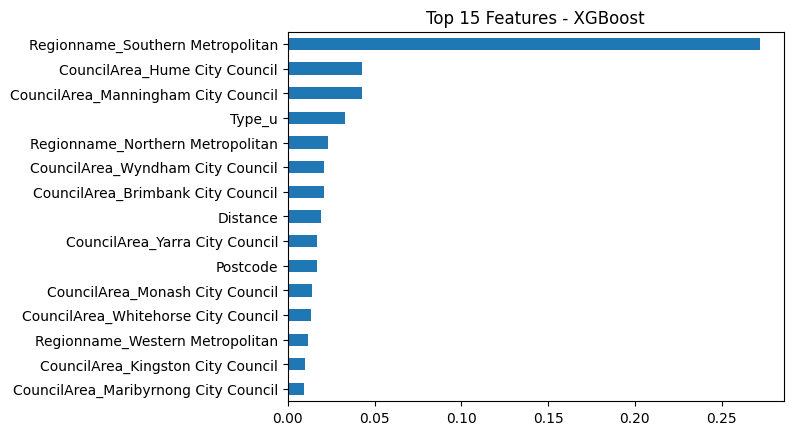

In [66]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

xgb_importance.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Features - XGBoost")
plt.show()

The chart shows that **location-related features** such as region and council area have the biggest impact on housing price predictions.  
Features like **distance from CBD and type of house** also play an important role in determining property prices.

In [74]:
feature_importance=pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})
feature_importance = feature_importance.sort_values(by="Importance", ascending=False).head(15)
feature_importance.to_csv('results/feature_importance.csv',index=False)

## Conclusion

In this project, I analysed the Melbourne housing market using both **macro and micro level analysis**.

The macro analysis showed that housing prices increased significantly from the **Pre-COVID period to the Post-COVID period**, indicating strong growth in the Victorian housing market.

In the micro analysis, I cleaned the housing dataset, explored important features, and built several machine learning models to predict property prices.

Among all the models tested, **XGBoost performed the best** with the highest R² score, showing better prediction accuracy.

The feature importance analysis also showed that **location-related factors, distance from the CBD, and property type** have a strong influence on housing prices.

Overall, the analysis shows that housing prices are strongly influenced by **location and market conditions**, and machine learning models can effectively be used to predict property prices.